## **Data Preprocessing**

In [ ]:
import os
import librosa
import numpy as np
import pandas as pd
import soundfile as sf
from tqdm import tqdm

In [11]:
AUDIO_DIR    = "Audio Wise V1.0-20220916T202003Z-001/Audio Wise V1.0"
METADATA_CSV = "Metadata-20220916T202011Z-001/Metadata/Metadata V1.0 FSC22.csv"
OUTPUT_DIR   = "processed_audio"
CSV_OUTPUT   = "metadata.csv"


SAMPLE_RATE  = 44100
DURATION     = 5.0
TOP_DB       = 30

In [12]:
THREAT_CLASSES = [
    "Fire",           # wildfire / arson
    "Helicopter",     # aerial poaching surveillance
    "VehicleEngine",  # illegal vehicle entry
    "Axe",            # illegal logging
    "Chainsaw",       # illegal logging
    "Generator",      # illegal camp equipment
    "Handsaw",        # illegal logging
    "Firework",       # poaching disturbance
    "Gunshot",        # poaching
    "WoodChop",       # illegal logging
    "TreeFalling",    # result of illegal logging
]

# WILDLIFE → normal forest background (no action needed)
# Rain, Thunderstorm, WaterDrops, Wind, Silence,
# Whistling, Speaking, Footsteps, Clapping,
# Insect, Frog, BirdChirping, WingFlaping,
# Lion, WolfHowl, Squirrel

def get_binary_label(class_name):
    return "threat" if class_name in THREAT_CLASSES else "wildlife"

In [10]:
print(os.listdir("Metadata-20220916T202011Z-001/Metadata"))

['.ipynb_checkpoints', 'Metadata V1.0 FSC22.csv', 'Metadata V1.0 FSC22_.xlsx']


In [13]:
meta = pd.read_csv(METADATA_CSV)
print(f"Total files in metadata: {len(meta)}")

Total files in metadata: 2025


In [14]:
print("\nBuilding file index from AUDIO_DIR...")
file_lookup = {}
for root, dirs, files in os.walk(AUDIO_DIR):
    for f in files:
        if f.lower().endswith(".wav"):
           file_lookup[f] = os.path.join(root, f)

print(f"WAV files found on disk: {len(file_lookup)}")


print("\nStep 1: Checking for corrupted files...")
valid_files = []

for _, row in tqdm(meta.iterrows(), total=len(meta)):
    filename  = row["Dataset File Name"]
    file_path = file_lookup.get(filename)          # look up actual path

    if file_path is None:
        print(f"  [MISSING] {filename}")
        continue

    try:
        audio, sr = librosa.load(file_path, sr=None)
        valid_files.append(filename)
    except Exception as e:
        print(f"  [CORRUPT] {filename} — {e}")

print(f"\nValid files: {len(valid_files)} / {len(meta)}")

meta = meta[meta["Dataset File Name"].isin(valid_files)].reset_index(drop=True)



Building file index from AUDIO_DIR...
WAV files found on disk: 2025

Step 1: Checking for corrupted files...


100%|██████████████████████████████████████████████████████████████████████████████| 2025/2025 [00:38<00:00, 51.97it/s]


Valid files: 2025 / 2025


In [15]:
def preprocess_audio(file_path, sr=SAMPLE_RATE, duration=DURATION):
    try:
        audio, _ = librosa.load(file_path, sr=sr, mono=True)
        audio, _ = librosa.effects.trim(audio, top_db=TOP_DB)

        target_length = int(sr * duration)
        if len(audio) < target_length:
            audio = np.pad(audio, (0, target_length - len(audio)))
        else:
            audio = audio[:target_length]

        return audio, sr
    except Exception as e:
        print(f"\n  [ERROR] {os.path.basename(file_path)}: {e}")
        return None, None


In [17]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

records = []
print("\nStep 2: Preprocessing audio files...")

for _ , row in tqdm(meta.iterrows(), total=len(meta)):
    filename     = row["Dataset File Name"]
    class_name   = row["Class Name"]
    binary_label = get_binary_label(class_name)
    file_path    = file_lookup.get(filename)       # use lookup, not raw join

    audio, sr = preprocess_audio(file_path)

    if audio is not None:
        out_dir  = os.path.join(OUTPUT_DIR, binary_label)
        os.makedirs(out_dir, exist_ok=True)

        out_name = f"{class_name}_{filename}"
        out_path = os.path.join(out_dir, out_name)
        sf.write(out_path, audio, sr)

        records.append({
            "filename"      : out_name,
            "original_class": class_name,
            "label"         : binary_label,
            "label_encoded" : 1 if binary_label == "threat" else 0,
            "sample_rate"   : sr,
            "duration_sec"  : DURATION,
            "processed_path": out_path
        })


Step 2: Preprocessing audio files...


100%|██████████████████████████████████████████████████████████████████████████████| 2025/2025 [00:41<00:00, 48.79it/s]


In [18]:
df = pd.DataFrame(records)
df.to_csv(CSV_OUTPUT, index=False)

In [20]:
print("\n" + "="*50)
print("   PREPROCESSING COMPLETE — FSC22")
print("="*50)
print(f"  Total processed  : {len(df)}")
print(f"  Wildlife         : {(df['label'] == 'wildlife').sum()}")
print(f"  Threat           : {(df['label'] == 'threat').sum()}")
print(f"  Output folder    : {OUTPUT_DIR}")
print(f"  CSV for Team 2   : {CSV_OUTPUT}")
print("="*50)

print("\n THREAT class breakdown:")
print(df[df['label'] == 'threat']['original_class'].value_counts().to_string())
print("\n WILDLIFE class breakdown:")
print(df[df['label'] == 'wildlife']['original_class'].value_counts().to_string())


   PREPROCESSING COMPLETE — FSC22
  Total processed  : 2025
  Wildlife         : 1200
  Threat           : 825
  Output folder    : processed_audio
  CSV for Team 2   : metadata.csv

 THREAT class breakdown:
original_class
Fire             75
TreeFalling      75
Helicopter       75
VehicleEngine    75
Axe              75
Chainsaw         75
Generator        75
Handsaw          75
Firework         75
Gunshot          75
WoodChop         75

 WILDLIFE class breakdown:
original_class
Rain            75
Thunderstorm    75
WaterDrops      75
Wind            75
Silence         75
Whistling       75
Speaking        75
Footsteps       75
Clapping        75
Insect          75
Frog            75
BirdChirping    75
WingFlaping     75
Lion            75
WolfHowl        75
Squirrel        75


## **Feature Extraction**

In [21]:
import pandas as pd

# Corrected path for Mac
CSV_OUTPUT = "metadata.csv"

# Read the file into a DataFrame
df = pd.read_csv(CSV_OUTPUT)
print(df.head())

           filename original_class   label  label_encoded  sample_rate  \
0  Fire_1_10101.wav           Fire  threat              1        44100   
1  Fire_1_10102.wav           Fire  threat              1        44100   
2  Fire_1_10103.wav           Fire  threat              1        44100   
3  Fire_1_10104.wav           Fire  threat              1        44100   
4  Fire_1_10105.wav           Fire  threat              1        44100   

   duration_sec                           processed_path  
0           5.0  processed_audio\threat\Fire_1_10101.wav  
1           5.0  processed_audio\threat\Fire_1_10102.wav  
2           5.0  processed_audio\threat\Fire_1_10103.wav  
3           5.0  processed_audio\threat\Fire_1_10104.wav  
4           5.0  processed_audio\threat\Fire_1_10105.wav  


In [22]:
SAMPLE_RATE     = 44100
DURATION        = 5.0
N_MFCC          = 40       # number of MFCC coefficients
N_MELS          = 128      # mel filterbanks
N_FFT           = 2048     # FFT window size
HOP_LENGTH      = 512

In [23]:
df = pd.read_csv(CSV_OUTPUT)
print(f"Loaded metadata: {len(df)} files")
print(df[['filename', 'original_class', 'label']].head())

Loaded metadata: 2025 files
           filename original_class   label
0  Fire_1_10101.wav           Fire  threat
1  Fire_1_10102.wav           Fire  threat
2  Fire_1_10103.wav           Fire  threat
3  Fire_1_10104.wav           Fire  threat
4  Fire_1_10105.wav           Fire  threat


In [24]:
def extract_features(file_path, sr=SAMPLE_RATE):
    """
    Extracts the following features from an audio file:
      - MFCCs (mean + std of 40 coefficients)        → 80 features
      - Delta MFCCs (mean + std)                     → 80 features
      - Delta-Delta MFCCs (mean + std)               → 80 features
      - Mel Spectrogram (mean + std of 128 bins)     → 256 features
      - Chroma STFT (mean + std of 12 bins)          → 24 features
      - Spectral Centroid (mean + std)               →  2 features
      - Spectral Bandwidth (mean + std)              →  2 features
      - Spectral Rolloff (mean + std)                →  2 features
      - Spectral Contrast (mean + std, 7 bands)      → 14 features
      - Zero Crossing Rate (mean + std)              →  2 features
      - RMS Energy (mean + std)                      →  2 features
      - Tonnetz (mean + std, 6 dims)                 → 12 features
    ─────────────────────────────────────────────────────────────
    TOTAL                                            → 556 features
    """
    try:
        audio, _ = librosa.load(file_path, sr=sr, mono=True)

        features = {}

        
        mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC,
                                     n_fft=N_FFT, hop_length=HOP_LENGTH)
        for i in range(N_MFCC):
            features[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
            features[f"mfcc_{i+1}_std"]  = np.std(mfcc[i])

       
        delta_mfcc = librosa.feature.delta(mfcc)
        for i in range(N_MFCC):
            features[f"delta_mfcc_{i+1}_mean"] = np.mean(delta_mfcc[i])
            features[f"delta_mfcc_{i+1}_std"]  = np.std(delta_mfcc[i])

       
        delta2_mfcc = librosa.feature.delta(mfcc, order=2)
        for i in range(N_MFCC):
            features[f"delta2_mfcc_{i+1}_mean"] = np.mean(delta2_mfcc[i])
            features[f"delta2_mfcc_{i+1}_std"]  = np.std(delta2_mfcc[i])

        
        mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=N_MELS,
                                              n_fft=N_FFT, hop_length=HOP_LENGTH)
        mel_db = librosa.power_to_db(mel, ref=np.max)
        for i in range(N_MELS):
            features[f"mel_{i+1}_mean"] = np.mean(mel_db[i])
            features[f"mel_{i+1}_std"]  = np.std(mel_db[i])

        
        chroma = librosa.feature.chroma_stft(y=audio, sr=sr,
                                              n_fft=N_FFT, hop_length=HOP_LENGTH)
        for i in range(chroma.shape[0]):
            features[f"chroma_{i+1}_mean"] = np.mean(chroma[i])
            features[f"chroma_{i+1}_std"]  = np.std(chroma[i])


        centroid = librosa.feature.spectral_centroid(y=audio, sr=sr,
                                                      n_fft=N_FFT, hop_length=HOP_LENGTH)
        features["spectral_centroid_mean"] = np.mean(centroid)
        features["spectral_centroid_std"]  = np.std(centroid)


        bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr,
                                                        n_fft=N_FFT, hop_length=HOP_LENGTH)
        features["spectral_bandwidth_mean"] = np.mean(bandwidth)
        features["spectral_bandwidth_std"]  = np.std(bandwidth)


        rolloff = librosa.feature.spectral_rolloff(y=audio, sr=sr,
                                                    n_fft=N_FFT, hop_length=HOP_LENGTH)
        features["spectral_rolloff_mean"] = np.mean(rolloff)
        features["spectral_rolloff_std"]  = np.std(rolloff)

        contrast = librosa.feature.spectral_contrast(y=audio, sr=sr,
                                                      n_fft=N_FFT, hop_length=HOP_LENGTH)
        for i in range(contrast.shape[0]):
            features[f"spectral_contrast_{i+1}_mean"] = np.mean(contrast[i])
            features[f"spectral_contrast_{i+1}_std"]  = np.std(contrast[i])

        zcr = librosa.feature.zero_crossing_rate(y=audio, hop_length=HOP_LENGTH)
        features["zcr_mean"] = np.mean(zcr)
        features["zcr_std"]  = np.std(zcr)

        rms = librosa.feature.rms(y=audio, hop_length=HOP_LENGTH)
        features["rms_mean"] = np.mean(rms)
        features["rms_std"]  = np.std(rms)

        harmonic = librosa.effects.harmonic(audio)
        if np.max(np.abs(harmonic)) > 0.01:   # only if not silent
            tonnetz = librosa.feature.tonnetz(y=harmonic, sr=sr)
        else:
            tonnetz = np.zeros((6, 1))
        for i in range(tonnetz.shape[0]):
            features[f"tonnetz_{i+1}_mean"] = np.mean(tonnetz[i])
            features[f"tonnetz_{i+1}_std"]  = np.std(tonnetz[i])

        return features

    except Exception as e:
        print(f"\n  [ERROR] {os.path.basename(file_path)}: {e}")
        return None

In [25]:
print("\n Extracting features...")

all_features = []
failed       = []

for _, row in tqdm(df.iterrows(), total=len(df)):
    feats = extract_features(row["processed_path"])

    if feats is not None:
        feats["filename"]       = row["filename"]
        feats["original_class"] = row["original_class"]
        feats["label"]          = row["label"]
        feats["label_encoded"]  = row["label_encoded"]
        all_features.append(feats)
    else:
        failed.append(row["filename"])



 Extracting features...


C:\Users\Aasim pasha\anaconda3\Lib\site-packages\librosa\core\pitch.py:103: UserWarning: Trying to estimate tuning from empty frequency set.
  return pitch_tuning(
100%|██████████████████████████████████████████████████████████████████████████████| 2025/2025 [25:41<00:00,  1.31it/s]


In [26]:
features_df = pd.DataFrame(all_features)
print("Feature shape:", features_df.shape)

Feature shape: (2025, 560)


In [27]:
features_df.to_csv("audio_features.csv", index=False)
print("Features saved to audio_features.csv")

Features saved to audio_features.csv


In [28]:
features_df.shape

(2025, 560)

In [29]:
features_df.isnull().sum()

mfcc_1_mean       0
mfcc_1_std        0
mfcc_2_mean       0
mfcc_2_std        0
mfcc_3_mean       0
                 ..
tonnetz_6_std     0
filename          0
original_class    0
label             0
label_encoded     0
Length: 560, dtype: int64

In [30]:
print(features_df["label"].value_counts())

label
wildlife    1200
threat       825
Name: count, dtype: int64


## **Model Development**

In [2]:
# 1. IMPORT LIBRARIES

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)


In [3]:

import matplotlib.pyplot as plt
import seaborn as sns



In [4]:


# 2. LOAD DATASET

features = pd.read_csv("audio_features.csv")

X = features.iloc[:, :-4]
y = features['label_encoded']



# 3. TRAIN TEST SPLIT

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)



# 4. FEATURE SCALING (FOR KNN & SVM)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)




RFC RESULTS
Accuracy: 0.8320987654320988
Precision: 0.8313794653663934
Recall: 0.8320987654320988
F1 Score: 0.8309783936413789
False Positive Rate: 0.11666666666666667
False Negative Rate: 0.24242424242424243

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       240
           1       0.82      0.76      0.79       165

    accuracy                           0.83       405
   macro avg       0.83      0.82      0.82       405
weighted avg       0.83      0.83      0.83       405



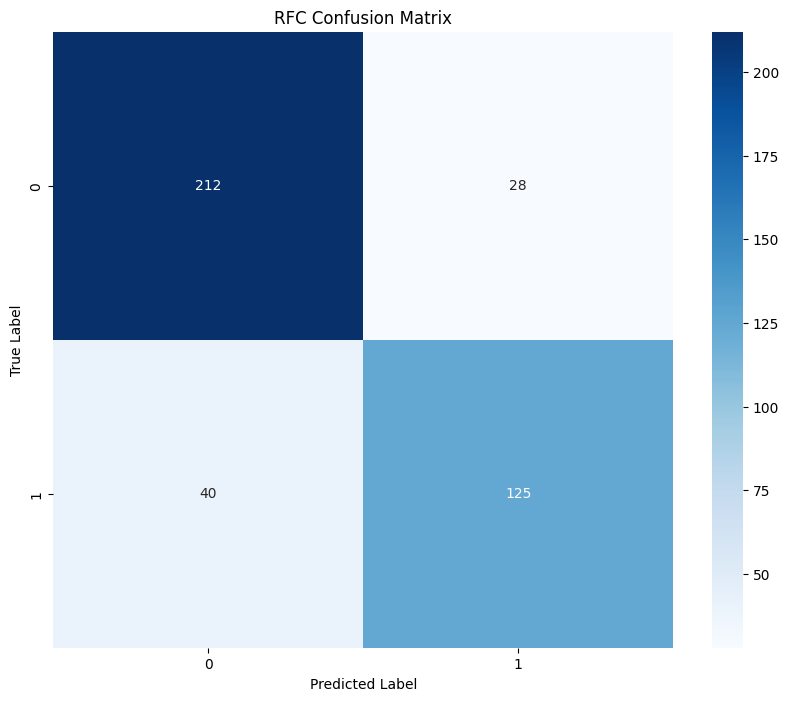

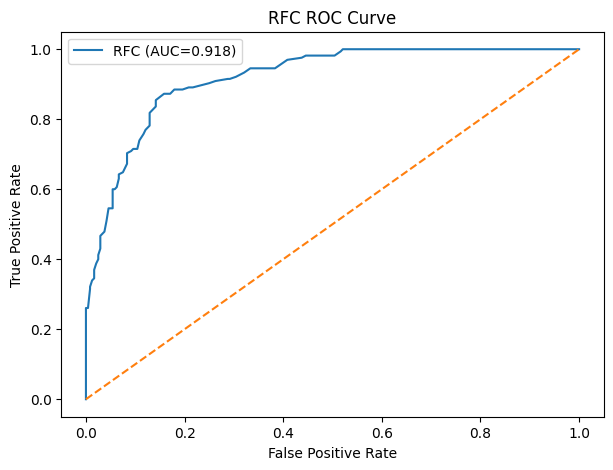

In [5]:

# 5. RANDOM FOREST MODEL DEVELOPMENT

rfc = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rfc.fit(X_train, y_train)

y_pred_rfc = rfc.predict(X_test)
y_prob_rfc = rfc.predict_proba(X_test)[:,1]



# 6. RANDOM FOREST MODEL EVALUATION


accuracy_rfc = accuracy_score(y_test, y_pred_rfc)
precision_rfc = precision_score(y_test, y_pred_rfc, average='weighted')
recall_rfc = recall_score(y_test, y_pred_rfc, average='weighted')
f1_rfc = f1_score(y_test, y_pred_rfc, average='weighted')

cm_rfc = confusion_matrix(y_test, y_pred_rfc)

TN, FP, FN, TP = cm_rfc.ravel()

fpr_rfc = FP / (FP + TN)
fnr_rfc = FN / (FN + TP)

print("RFC RESULTS")
print("Accuracy:", accuracy_rfc)
print("Precision:", precision_rfc)
print("Recall:", recall_rfc)
print("F1 Score:", f1_rfc)
print("False Positive Rate:", fpr_rfc)
print("False Negative Rate:", fnr_rfc)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rfc))

plt.figure(figsize=(10,8))
sns.heatmap(cm_rfc, annot=True, fmt='d', cmap='Blues')
plt.title("RFC Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# RFC ROC Curve
fpr_rfc_curve, tpr_rfc_curve, _ = roc_curve(y_test, y_prob_rfc)
auc_rfc = roc_auc_score(y_test, y_prob_rfc)

plt.figure(figsize=(7,5))
plt.plot(fpr_rfc_curve, tpr_rfc_curve, label=f"RFC (AUC={auc_rfc:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("RFC ROC Curve")
plt.legend()
plt.show()




KNN RESULTS
Accuracy: 0.7654320987654321
Precision: 0.7637597757119671
Recall: 0.7654320987654321
F1 Score: 0.7640153672880691
False Positive Rate: 0.175
False Negative Rate: 0.3212121212121212

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       240
           1       0.73      0.68      0.70       165

    accuracy                           0.77       405
   macro avg       0.76      0.75      0.75       405
weighted avg       0.76      0.77      0.76       405



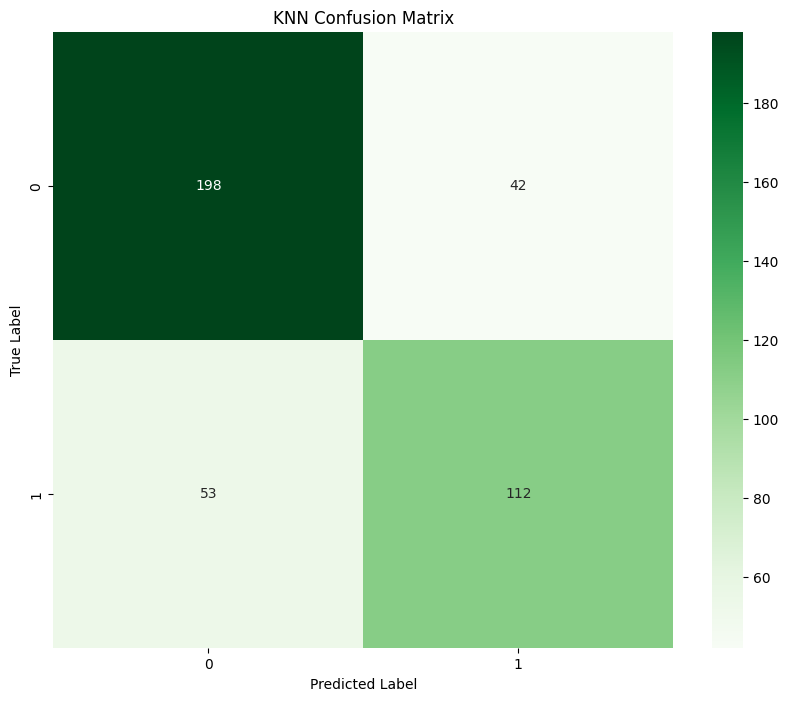

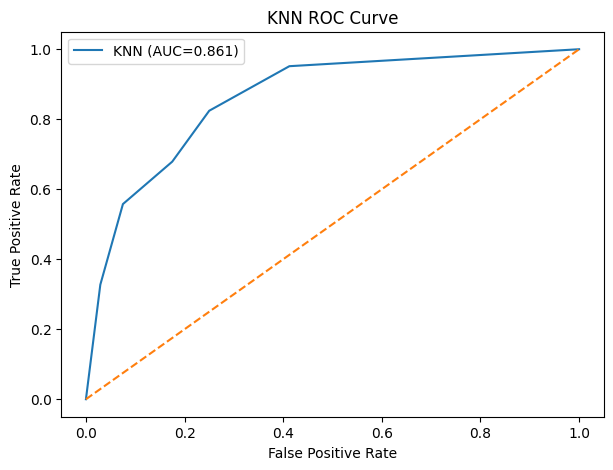

In [6]:


# 7. KNN MODEL DEVELOPMENT


knn = KNeighborsClassifier(
    n_neighbors=5,
    n_jobs=-1
)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)
y_prob_knn = knn.predict_proba(X_test_scaled)[:,1]



# 8. KNN MODEL EVALUATION


accuracy_knn = accuracy_score(y_test, y_pred_knn)
precision_knn = precision_score(y_test, y_pred_knn, average='weighted')
recall_knn = recall_score(y_test, y_pred_knn, average='weighted')
f1_knn = f1_score(y_test, y_pred_knn, average='weighted')

cm_knn = confusion_matrix(y_test, y_pred_knn)

TN, FP, FN, TP = cm_knn.ravel()

fpr_knn = FP / (FP + TN)
fnr_knn = FN / (FN + TP)

print("\nKNN RESULTS")
print("Accuracy:", accuracy_knn)
print("Precision:", precision_knn)
print("Recall:", recall_knn)
print("F1 Score:", f1_knn)
print("False Positive Rate:", fpr_knn)
print("False Negative Rate:", fnr_knn)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

plt.figure(figsize=(10,8))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens')
plt.title("KNN Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# KNN ROC Curve
fpr_knn_curve, tpr_knn_curve, _ = roc_curve(y_test, y_prob_knn)
auc_knn = roc_auc_score(y_test, y_prob_knn)

plt.figure(figsize=(7,5))
plt.plot(fpr_knn_curve, tpr_knn_curve, label=f"KNN (AUC={auc_knn:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("KNN ROC Curve")
plt.legend()
plt.show()


SVM RESULTS
Accuracy: 0.8740740740740741
Precision: 0.8736967377873441
Recall: 0.8740740740740741
F1 Score: 0.8736145634448887
False Positive Rate: 0.09166666666666666
False Negative Rate: 0.17575757575757575

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       240
           1       0.86      0.82      0.84       165

    accuracy                           0.87       405
   macro avg       0.87      0.87      0.87       405
weighted avg       0.87      0.87      0.87       405



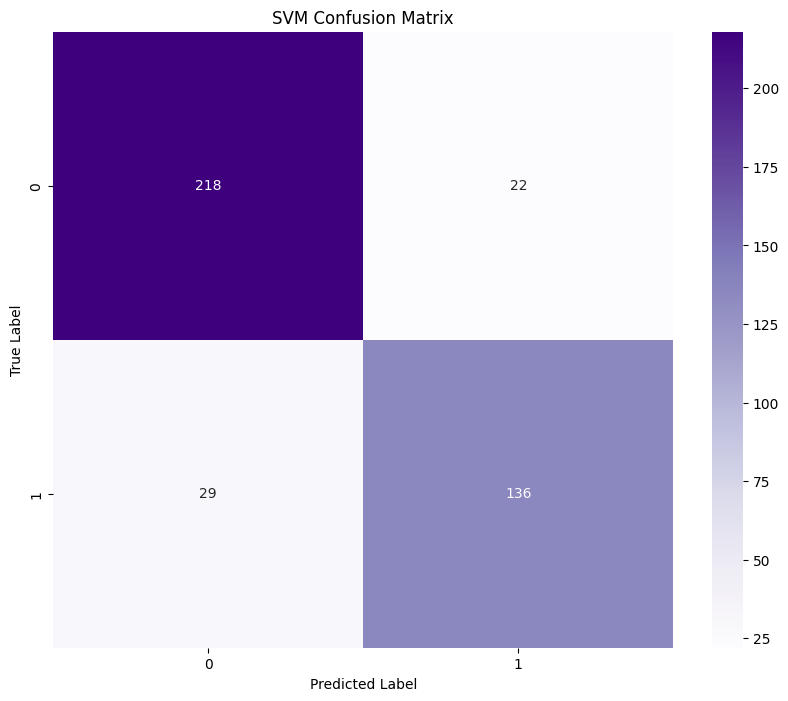

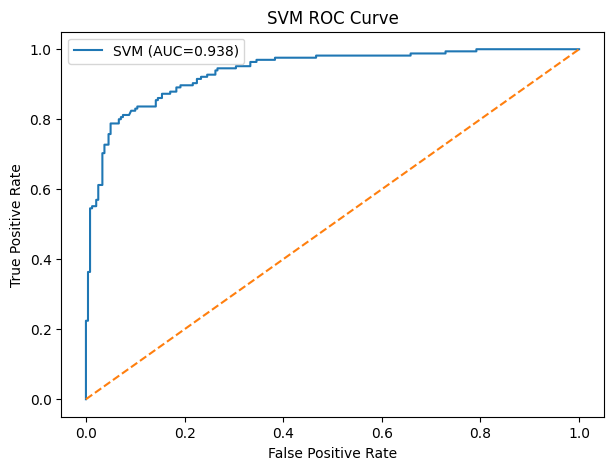

In [7]:

# 9. SVM MODEL DEVELOPMENT


svm = SVC(
    kernel='rbf',
    C=10,
    gamma='scale',
    probability=True,
    random_state=42
)

svm.fit(X_train_scaled, y_train)

y_pred_svm = svm.predict(X_test_scaled)
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]



# 10. SVM MODEL EVALUATION


accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm, average='weighted')
recall_svm = recall_score(y_test, y_pred_svm, average='weighted')
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')

cm_svm = confusion_matrix(y_test, y_pred_svm)

TN, FP, FN, TP = cm_svm.ravel()

fpr_svm = FP / (FP + TN)
fnr_svm = FN / (FN + TP)

print("\nSVM RESULTS")
print("Accuracy:", accuracy_svm)
print("Precision:", precision_svm)
print("Recall:", recall_svm)
print("F1 Score:", f1_svm)
print("False Positive Rate:", fpr_svm)
print("False Negative Rate:", fnr_svm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_svm))

plt.figure(figsize=(10,8))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples')
plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

# SVM ROC Curve
fpr_svm_curve, tpr_svm_curve, _ = roc_curve(y_test, y_prob_svm)
auc_svm = roc_auc_score(y_test, y_prob_svm)

plt.figure(figsize=(7,5))
plt.plot(fpr_svm_curve, tpr_svm_curve, label=f"SVM (AUC={auc_svm:.3f})")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()
plt.show()

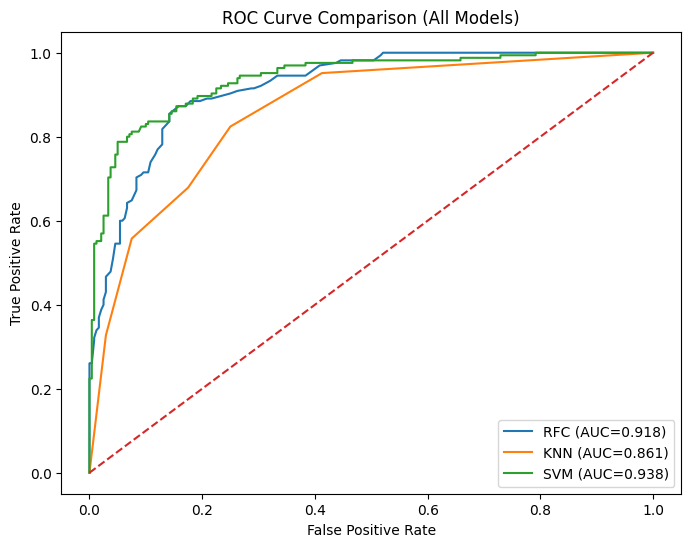

In [8]:


plt.figure(figsize=(8,6))

plt.plot(fpr_rfc_curve, tpr_rfc_curve, label=f"RFC (AUC={auc_rfc:.3f})")
plt.plot(fpr_knn_curve, tpr_knn_curve, label=f"KNN (AUC={auc_knn:.3f})")
plt.plot(fpr_svm_curve, tpr_svm_curve, label=f"SVM (AUC={auc_svm:.3f})")

plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison (All Models)")
plt.legend()

plt.show()

In [9]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.pipeline import Pipeline

kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Random Forest — no scaling needed
cv_rfc = cross_val_score(rfc, X, y, cv=kfold, scoring='accuracy')

# KNN — scaling inside pipeline
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=5, n_jobs=-1))
])
cv_knn = cross_val_score(knn_pipeline, X, y, cv=kfold, scoring='accuracy')

# SVM — scaling inside pipeline
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                probability=True, random_state=42))
])
cv_svm = cross_val_score(svm_pipeline, X, y, cv=kfold, scoring='accuracy')

print("CROSS VALIDATION RESULTS")
print(f"RFC CV Scores : {cv_rfc}")
print(f"RFC CV Average: {cv_rfc.mean():.4f}\n")

print(f"KNN CV Scores : {cv_knn}")
print(f"KNN CV Average: {cv_knn.mean():.4f}\n")

print(f"SVM CV Scores : {cv_svm}")
print(f"SVM CV Average: {cv_svm.mean():.4f}")

CROSS VALIDATION RESULTS
RFC CV Scores : [0.89382716 0.85925926 0.9037037  0.8691358  0.87160494]
RFC CV Average: 0.8795

KNN CV Scores : [0.84197531 0.79012346 0.80246914 0.83209877 0.81975309]
KNN CV Average: 0.8173

SVM CV Scores : [0.89876543 0.87407407 0.89876543 0.89876543 0.88395062]
SVM CV Average: 0.8909


In [10]:
# FINAL COMPARISON DATAFRAME

comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "KNN", "SVM"],

    "Accuracy": [
        accuracy_rfc,
        accuracy_knn,
        accuracy_svm
    ],

    "Precision": [
        precision_rfc,
        precision_knn,
        precision_svm
    ],

    "Recall": [
        recall_rfc,
        recall_knn,
        recall_svm
    ],

    "F1 Score": [
        f1_rfc,
        f1_knn,
        f1_svm
    ],

    "False Positive Rate": [
        fpr_rfc,
        fpr_knn,
        fpr_svm
    ],

    "False Negative Rate": [
        fnr_rfc,
        fnr_knn,
        fnr_svm
    ]
})

# Display the dataframe
print("\nMODEL COMPARISON TABLE")
display(comparison_df)


MODEL COMPARISON TABLE


,Model,Accuracy,Precision,Recall,F1 Score,False Positive Rate,False Negative Rate
0,Random Forest,0.832099,0.831379,0.832099,0.830978,0.116667,0.242424
1,KNN,0.765432,0.763760,0.765432,0.764015,0.175000,0.321212
2,SVM,0.874074,0.873697,0.874074,0.873615,0.091667,0.175758


## **Model Evaluation**

In [11]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import pandas as pd

# Predictions
knn_pred = knn.predict(X_test_scaled)
svm_pred = svm.predict(X_test_scaled)
rf_pred = rfc.predict(X_test)


# Confusion Matrices

cm_knn = confusion_matrix(y_test, knn_pred)
cm_svm = confusion_matrix(y_test, svm_pred)
cm_rf = confusion_matrix(y_test, rf_pred)

print("KNN Confusion Matrix:\n", cm_knn)
print("\nSVM Confusion Matrix:\n", cm_svm)
print("\nRandom Forest Confusion Matrix:\n", cm_rf)


# Classification Reports

print("\nKNN Classification Report")
print(classification_report(y_test, knn_pred))

print("\nSVM Classification Report")
print(classification_report(y_test, svm_pred))

print("\nRandom Forest Classification Report")
print(classification_report(y_test, rf_pred))


# Accuracy

acc_knn = accuracy_score(y_test, knn_pred)
acc_svm = accuracy_score(y_test, svm_pred)
acc_rf = accuracy_score(y_test, rf_pred)


# False Positive Rate

def calculate_fpr(cm):
    tn, fp, fn, tp = cm.ravel()
    return fp / (fp + tn)

fpr_knn = calculate_fpr(cm_knn)
fpr_svm = calculate_fpr(cm_svm)
fpr_rf = calculate_fpr(cm_rf)

print("\nFalse Positive Rates")
print("KNN:", fpr_knn)
print("Random Forest:", fpr_rf)
print("SVM:", fpr_svm)


# Model Comparison Table

comparison = pd.DataFrame({
    "Model": ["KNN", "Random Forest", "SVM"],
    "Test Accuracy": [acc_knn, acc_rf, acc_svm],
    "False Positive Rate": [fpr_knn, fpr_rf, fpr_svm]
})

print("\nModel Comparison Table")
print(comparison)

KNN Confusion Matrix:
 [[198  42]
 [ 53 112]]

SVM Confusion Matrix:
 [[218  22]
 [ 29 136]]

Random Forest Confusion Matrix:
 [[212  28]
 [ 40 125]]

KNN Classification Report
              precision    recall  f1-score   support

           0       0.79      0.82      0.81       240
           1       0.73      0.68      0.70       165

    accuracy                           0.77       405
   macro avg       0.76      0.75      0.75       405
weighted avg       0.76      0.77      0.76       405


SVM Classification Report
              precision    recall  f1-score   support

           0       0.88      0.91      0.90       240
           1       0.86      0.82      0.84       165

    accuracy                           0.87       405
   macro avg       0.87      0.87      0.87       405
weighted avg       0.87      0.87      0.87       405


Random Forest Classification Report
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       

Model Recommendation


After evaluating the performance of the three models — KNN, Random Forest, and Support Vector Machine (SVM) — using confusion matrices, classification reports, test accuracy, and false positive rates, it was observed that SVM achieved the best overall performance. SVM obtained the highest test accuracy of approximately 87% and the lowest false positive rate of about 9%, indicating that it produces fewer false alarms compared to the other models. In a forest monitoring system, minimizing false positives is important to avoid unnecessary alerts for normal wildlife sounds. Therefore, SVM is recommended as the final model for detecting threat sounds in the dataset due to its higher accuracy and better reliability.